In [1]:
# Cell 1 — tell Python where the project root is
import sys
import os
import itables 
itables.options.maxBytes = 0
# This makes sure imports work regardless of where the notebook lives
project_root = "/Users/bradybrown/Documents/projects/wnba"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Path set. Project root:", project_root)

Path set. Project root: /Users/bradybrown/Documents/projects/wnba


In [2]:
# Cell 2
from data.cache import get_shot_chart
from viz.shotchart import shot_scatter, shot_hexmap
import matplotlib.pyplot as plt

print("Imports OK")

CORNER_TOP_Y: 27.8, THREE_THETA: 7.2°
Imports OK


In [3]:
# Cell 3 — pull the data
df_all = get_shot_chart(season="2025")
clark = df_all[df_all["PLAYER_NAME"] == "Angel Reese"].copy()
print(f"Angel Reese 2025: {len(clark)} shots")

[cache] HIT — loading shot_chart_5cb71983.csv
Angel Reese 2025: 334 shots


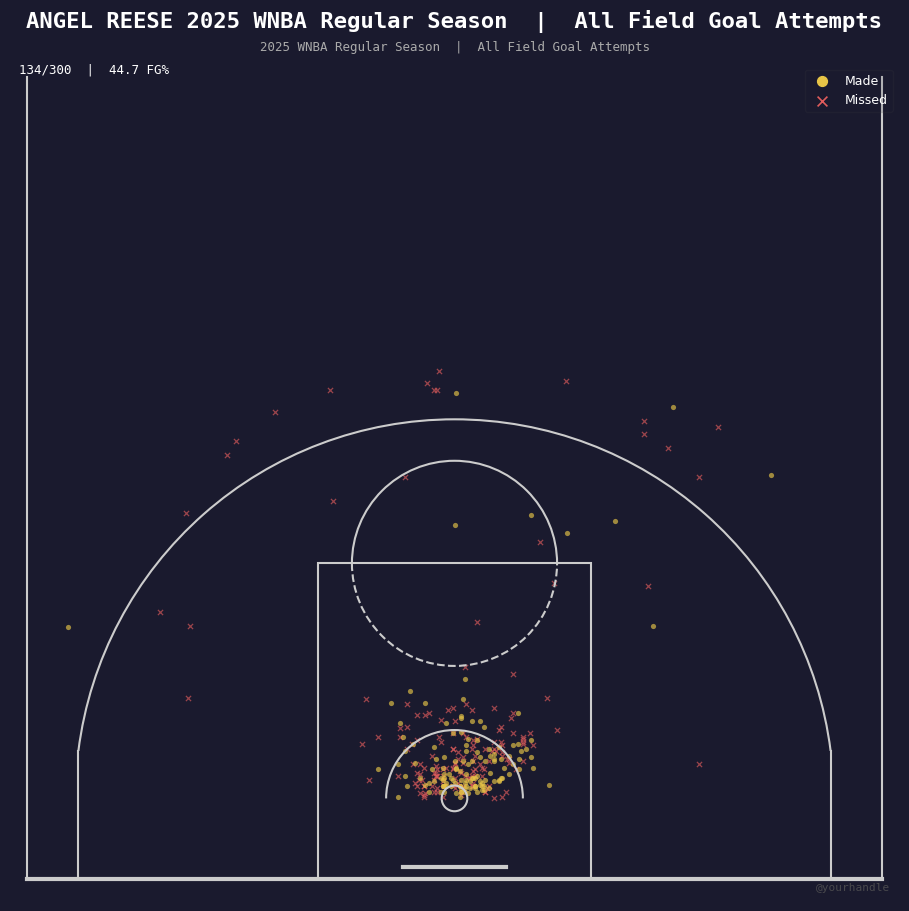

In [4]:
# Cell 4 — scatter
fig = shot_scatter(
    clark,
    title="ANGEL REESE 2025 WNBA Regular Season  |  All Field Goal Attempts",
    subtitle="2025 WNBA Regular Season  |  All Field Goal Attempts",
    watermark="@yourhandle",
)
plt.show()

In [5]:
from data.rapm import compute_rapm

# Single season
#nrapm = compute_rapm("2024")

# Multiple seasons (more stable estimates)
rapm = compute_rapm(["2025"], ridge_alpha = 'auto',filter_garbage_time=True)

# If you already built stints and want to re-run the model with different alpha:
# from data.stints import build_stints
# stints_df, names = build_stints('2025')
# rapm = compute_rapm(['2025'], stints_df=stints_df, name_lookup=names, ridge_alpha=1500)

# print(rapm.head(20))


Fetching stints for: ['2025']
[cache] HIT — loading game_ids_101086b3.csv
  [1/286] game 1022500285
[cache] HIT — loading rotation_86699638.csv
[cache] HIT — loading pbp_86699638.csv
[cache] HIT — loading rotation_7a5df013.csv
[cache] HIT — loading pbp_7a5df013.csv
[cache] HIT — loading rotation_27e5599a.csv
[cache] HIT — loading pbp_27e5599a.csv
[cache] HIT — loading rotation_4e345b58.csv
[cache] HIT — loading pbp_4e345b58.csv
[cache] HIT — loading rotation_03959450.csv
[cache] HIT — loading pbp_03959450.csv
[cache] HIT — loading rotation_73055868.csv
[cache] HIT — loading pbp_73055868.csv
[cache] HIT — loading rotation_2c0c8cb4.csv
[cache] HIT — loading pbp_2c0c8cb4.csv
[cache] HIT — loading rotation_302c87a8.csv
[cache] HIT — loading pbp_302c87a8.csv
[cache] HIT — loading rotation_dbbba46e.csv
[cache] HIT — loading pbp_dbbba46e.csv
[cache] HIT — loading rotation_71b50464.csv
[cache] HIT — loading pbp_71b50464.csv
[cache] HIT — loading rotation_41fe135b.csv
[cache] HIT — loading pbp_

In [6]:

poss_threshold = 1000

rapm_display = rapm[(rapm["POSS"] >= poss_threshold)].copy()
itables.show(rapm_display)

Loading ITables v2.8.0 from the internet... (need help?)


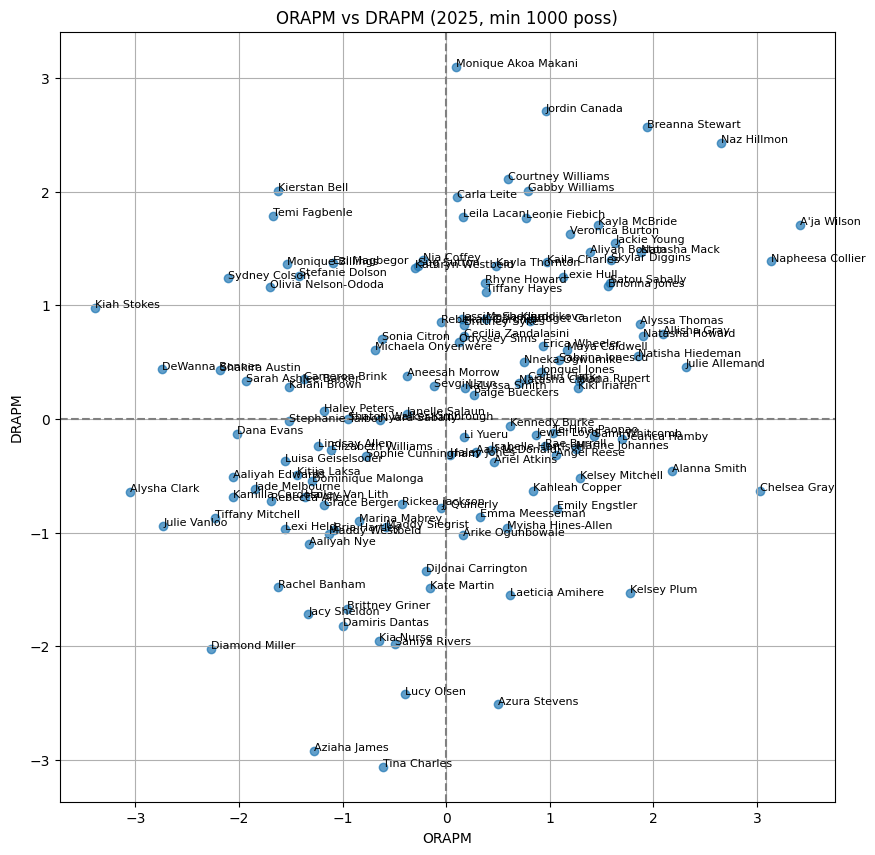

In [7]:
# create a four quadrant plot of offense vs defense RAPM, with small name labels
plt.figure(figsize=(10, 10))
plt.scatter(rapm_display["ORAPM"], rapm_display["DRAPM"], alpha=0.7)
for i, row in rapm_display.iterrows():
    plt.text(row["ORAPM"], row["DRAPM"], row["PLAYER_NAME"], fontsize=8)
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.title("ORAPM vs DRAPM (2025, min 1000 poss)")
plt.xlabel("ORAPM")
plt.ylabel("DRAPM")
plt.grid(True)
plt.show()

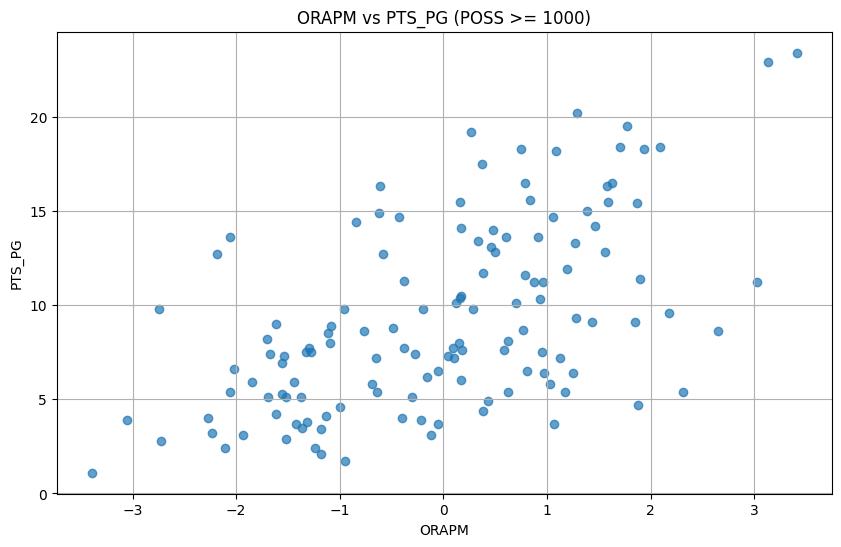

Correlation between ORAPM and PTS_PG: 0.57


In [8]:
# build a scatter plot of ORAPM versus PTS_PG, then find correlation 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(rapm_display["ORAPM"], rapm_display["PTS_PG"], alpha=0.7)
plt.title("ORAPM vs PTS_PG (POSS >= 1000)")
plt.xlabel("ORAPM")  # You might want to label this more clearly based on what ORAPM represents
plt.ylabel("PTS_PG")
plt.grid(True)
plt.show()
correlation = rapm_display["ORAPM"].corr(rapm_display["PTS_PG"])
print(f"Correlation between ORAPM and PTS_PG: {correlation:.2f}")

In [9]:
import pandas as pd
import itables
from data.cache import get_team_ratings

seasons = ["2023", "2024", "2025"]

frames = []
for s in seasons:
    df = get_team_ratings(s)
    df["SEASON"] = s
    frames.append(df)

ratings = pd.concat(frames, ignore_index=True)
print(ratings.columns)
display_cols = ["SEASON", "TEAM_NAME", "GP", "W", "L", "OFF_RATING", "DEF_RATING", "NET_RATING", "PACE"]
ratings = ratings[display_cols].sort_values(["SEASON", "NET_RATING"], ascending=[True, False])

itables.show(
    ratings,
    caption="WNBA Team Ratings & Pace by Season",
    paging=True,
    pageLength=12,
)

[cache] HIT — loading team_ratings_e78e5c1d.csv
[cache] HIT — loading team_ratings_0dc05ec5.csv
[cache] HIT — loading team_ratings_101086b3.csv
Index(['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'OFF_RATING', 'DEF_RATING',
       'NET_RATING', 'PACE', 'SEASON'],
      dtype='str')


Loading ITables v2.8.0 from the internet... (need help?)


In [10]:
import pandas as pd
import itables
from data.cache import get_player_stats

seasons = ["2023", "2024", "2025"]

frames = []
for s in seasons:
    pg, _ = get_player_stats(s, measure_type="Advanced")
    pg["SEASON"] = s
    frames.append(pg)

player_adv = pd.concat(frames, ignore_index=True)

min_threshold = 10
display_cols = ["SEASON", "PLAYER_NAME", "TEAM_ABBREVIATION", "GP", "MIN",
                "USG_PCT", "TS_PCT", "AST_PCT", "OREB_PCT", "DREB_PCT", "PIE"]
player_adv_display = (
    player_adv[player_adv["MIN"] >= min_threshold][display_cols]
    .sort_values(["SEASON", "USG_PCT"], ascending=[True, False])
)

itables.show(
    player_adv_display,
    caption="WNBA Player Advanced Stats (USG%, TS%, etc.) by Season",
    paging=True,
    pageLength=20,
)

[cache] HIT — loading player_stats_10d0f2ba.csv
[cache] HIT — loading player_stats_466a7812.csv
[cache] HIT — loading player_stats_300de08d.csv
[cache] HIT — loading player_stats_e815f36f.csv
[cache] HIT — loading player_stats_62f29cdd.csv
[cache] HIT — loading player_stats_bd521a23.csv


Loading ITables v2.8.0 from the internet... (need help?)


In [11]:
import itables

adv_cols = ["PLAYER_ID", "GP", "MIN",
            "TS_PCT", "AST_PCT", "OREB_PCT", "DREB_PCT", "PIE"]

adv_2025 = player_adv[player_adv["SEASON"] == "2025"][adv_cols]

rapm_adv = rapm.merge(adv_2025, on="PLAYER_ID", how="left")

itables.show(
    rapm_adv,
    caption="2025 RAPM + Advanced Stats",
    paging=True,
    pageLength=20,
)

Loading ITables v2.8.0 from the internet... (need help?)


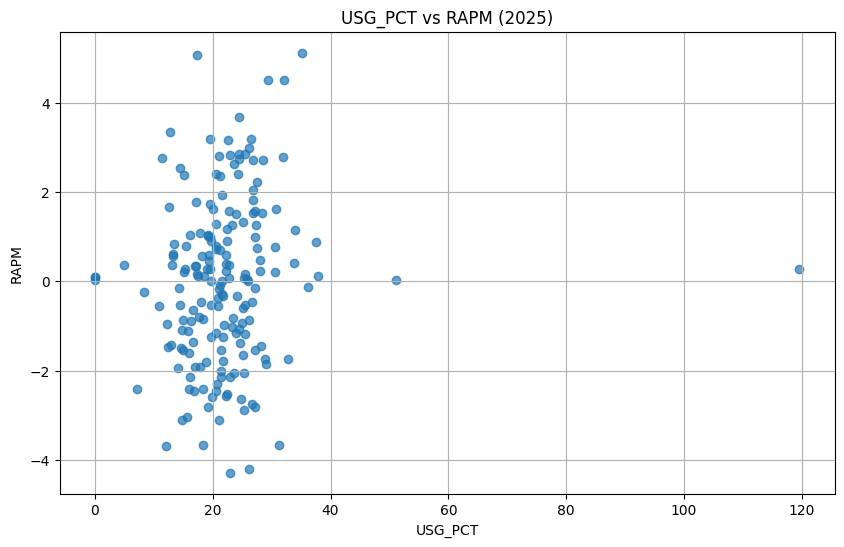

Correlation between USG_PCT and RAPM: 0.11


In [12]:
# show correlation between USG_PCT and RAPM
plt.figure(figsize=(10, 6))
plt.scatter(rapm_adv["USG_PCT"], rapm_adv["RAPM"], alpha=0.7)
plt.title("USG_PCT vs RAPM (2025)")
plt.xlabel("USG_PCT")
plt.ylabel("RAPM")
plt.grid(True)
plt.show()
correlation = rapm_adv["USG_PCT"].corr(rapm_adv["RAPM"])
print(f"Correlation between USG_PCT and RAPM: {correlation:.2f}")

In [13]:
import importlib
import data.bpm
importlib.reload(data.bpm)
from data.bpm import compute_bpm, fit_bpm, apply_bpm

# In-sample: fit and score on same season
# bpm = compute_bpm("2025", filter_garbage_time=True)

# Better: fit on multi-season RAPM, score on 2025
# training = compute_rapm(["2023","2024","2025"], ridge_alpha="auto", filter_garbage_time=True)
# bpm = compute_bpm("2025", training_rapm=training)

# If you already have rapm from above, skip the internal compute_rapm call:
o_info, d_info = fit_bpm(rapm)
bpm = apply_bpm(rapm, o_info, d_info)

itables.show(
    bpm[["PLAYER_NAME", "TEAM_ABBREVIATION", "POSS", "USG_PCT", "TS_PCT",
         "OBPM", "DBPM", "BPM", "ORAPM", "DRAPM", "RAPM"]].sort_values("BPM", ascending=False),
    caption="2025 WNBA BPM (calibrated against RAPM)",
    paging=True,
    pageLength=20,
)

BPM fit on 149 players (min_poss=500)
  OBPM features: AST_100=+0.585, TOV_100=-0.313, USG_PCT=+0.359, TS_PCT=+0.691
  DBPM features: STL_100=+0.356, BLK_100=+0.040, DREB_100=+0.176, OREB_100=-0.081


Loading ITables v2.8.0 from the internet... (need help?)


In [14]:
from scipy.stats import pearsonr
# Calculate Pearson correlation coefficient and p-value
# get rid of nans in bpm for bpm and rapm
bpm = bpm.dropna(subset=['BPM', 'RAPM'])
correlation, p_value = pearsonr(bpm['BPM'], bpm['RAPM'])
print(f"Correlation between BPM and RAPM: {correlation:.2f} (p-value: {p_value:.4f})")

Correlation between BPM and RAPM: 0.40 (p-value: 0.0000)


In [15]:
from scipy.stats import pearsonr
# Calculate Pearson correlation coefficient and p-value
# get rid of nans in bpm for bpm and rapm
bpm = bpm.dropna(subset=['OBPM', 'RAPM'])
correlation, p_value = pearsonr(bpm['OBPM'], bpm['RAPM'])
print(f"Correlation between OBPM and RAPM: {correlation:.2f} (p-value: {p_value:.4f})")

Correlation between OBPM and RAPM: 0.33 (p-value: 0.0000)


In [16]:
from scipy.stats import pearsonr
# Calculate Pearson correlation coefficient and p-value
# get rid of nans in bpm for bpm and rapm
bpm = bpm.dropna(subset=['DBPM', 'RAPM'])
correlation, p_value = pearsonr(bpm['DBPM'], bpm['RAPM'])
print(f"Correlation between DBPM and RAPM: {correlation:.2f} (p-value: {p_value:.4f})")

Correlation between DBPM and RAPM: 0.25 (p-value: 0.0009)


In [17]:
# ── EVALUATION 1: Discrimination ─────────────────────────────────────────────
# How much of RAPM is signal vs. noise?
# Uses split-half resampling: split stints 50/50, fit ridge on each half,
# correlate per-player estimates, apply Spearman-Brown to get full-season reliability.
#
# alpha must match the value used for your full-data fit.
# rapm was built with ridge_alpha='auto' above — check its CV output for the
# chosen value, or just pass a fixed value like 4000.

from data.stints import build_stints
from data.evaluation import rapm_discrimination, print_discrimination

stints_2025, _ = build_stints("2025")  # instant — fully cached

ALPHA = 4000.0  # hold constant across splits; replace if you know the auto-selected value

disc_2025 = rapm_discrimination(
    stints_2025,
    alpha=ALPHA,
    n_splits=20,
    min_poss_per_half=250,
)
print_discrimination(disc_2025)
disc_2025

[cache] HIT — loading game_ids_101086b3.csv
  [1/286] game 1022500285
[cache] HIT — loading rotation_86699638.csv
[cache] HIT — loading pbp_86699638.csv
[cache] HIT — loading rotation_7a5df013.csv
[cache] HIT — loading pbp_7a5df013.csv
[cache] HIT — loading rotation_27e5599a.csv
[cache] HIT — loading pbp_27e5599a.csv
[cache] HIT — loading rotation_4e345b58.csv
[cache] HIT — loading pbp_4e345b58.csv
[cache] HIT — loading rotation_03959450.csv
[cache] HIT — loading pbp_03959450.csv
[cache] HIT — loading rotation_73055868.csv
[cache] HIT — loading pbp_73055868.csv
[cache] HIT — loading rotation_2c0c8cb4.csv
[cache] HIT — loading pbp_2c0c8cb4.csv
[cache] HIT — loading rotation_302c87a8.csv
[cache] HIT — loading pbp_302c87a8.csv
[cache] HIT — loading rotation_dbbba46e.csv
[cache] HIT — loading pbp_dbbba46e.csv
[cache] HIT — loading rotation_71b50464.csv
[cache] HIT — loading pbp_71b50464.csv
[cache] HIT — loading rotation_41fe135b.csv
[cache] HIT — loading pbp_41fe135b.csv
[cache] HIT — loa

,metric,r_raw,reliability,n_players_avg,n_splits_used
0,ORAPM,0.433,0.604,149.3,20
1,DRAPM,0.351,0.520,149.3,20
2,RAPM,0.529,0.692,149.3,20


Independence: 149 players, 15 metrics
  7 component(s) explain ≥90% of variance (of 15 total metrics)


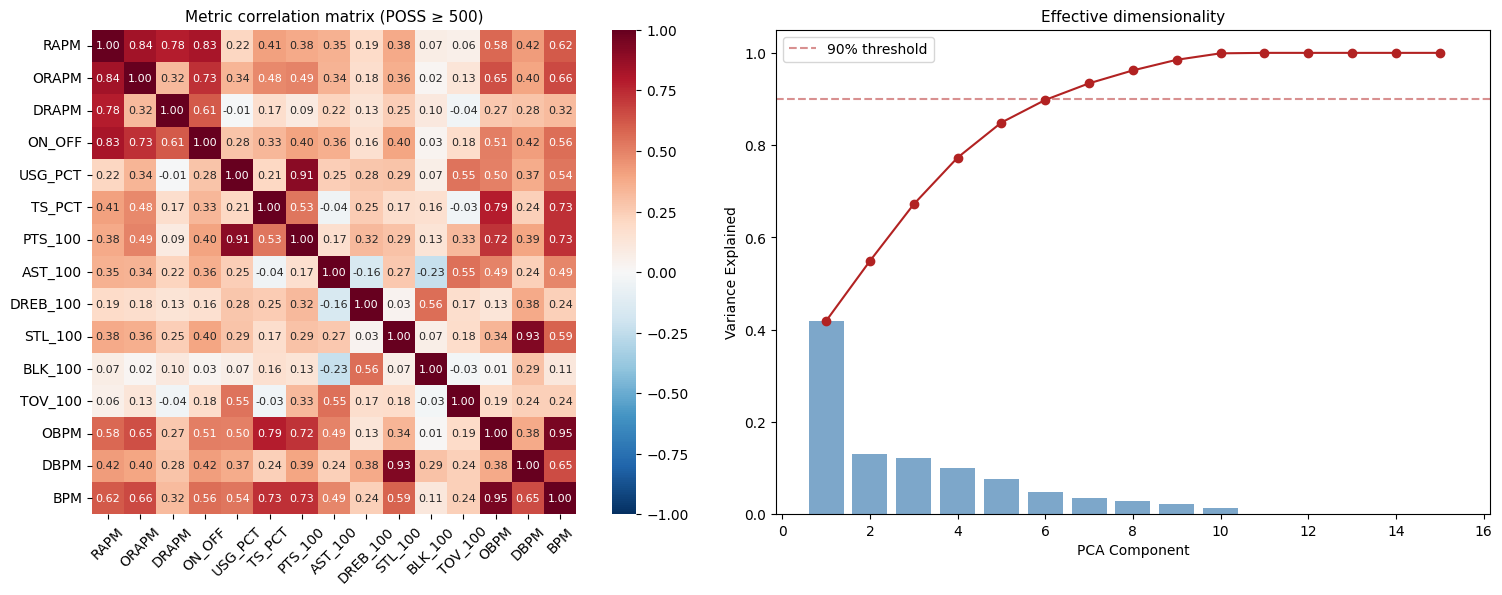


PCA breakdown:
 component  explained_variance  cumulative_variance
         1               0.419                0.419
         2               0.130                0.549
         3               0.123                0.672
         4               0.101                0.773
         5               0.076                0.849
         6               0.049                0.898
         7               0.036                0.934
         8               0.029                0.962
         9               0.022                0.985
        10               0.014                0.999
        11               0.001                1.000
        12               0.000                1.000
        13               0.000                1.000
        14               0.000                1.000
        15               0.000                1.000


In [18]:
# ── EVALUATION 2: Independence ────────────────────────────────────────────────
# How redundant are the metrics? Correlation matrix + PCA.
# Pass the bpm df (which has OBPM/DBPM/BPM) as rapm_df since it's a superset.

import matplotlib.pyplot as plt
import seaborn as sns
from data.evaluation import independence

corr_df, pca_df = independence(bpm, min_poss=500, extra_cols=["OBPM", "DBPM", "BPM"])

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=axes[0], square=True,
    annot_kws={"size": 8}
)
axes[0].set_title("Metric correlation matrix (POSS ≥ 500)", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)

# PCA scree
axes[1].bar(pca_df["component"], pca_df["explained_variance"], color="steelblue", alpha=0.7)
axes[1].plot(pca_df["component"], pca_df["cumulative_variance"], "o-", color="firebrick")
axes[1].axhline(0.9, color="firebrick", linestyle="--", alpha=0.5, label="90% threshold")
axes[1].set_xlabel("PCA Component")
axes[1].set_ylabel("Variance Explained")
axes[1].set_title("Effective dimensionality", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nPCA breakdown:")
print(pca_df.to_string(index=False))

In [19]:
# ── EVALUATION 3: Stability ───────────────────────────────────────────────────
# How much of each metric persists year-over-year?
# Computes RAPM separately per season, correlates across seasons for
# players appearing in consecutive years, normalizes by discrimination.
#
# Note: this cell takes a few minutes — it builds stints for 3 seasons
# (all cached) and fits 3 ridge regressions, then runs discrimination for
# each to get the attenuation-corrected stability.

from data.rapm import compute_rapm
from data.evaluation import stability, rapm_discrimination, print_stability
from data.stints import build_stints

# Build per-season RAPM (cached stints → fast)
rapm_by_season = {}
disc_by_season = {}

for season in ['2020','2021','2022','2023', '2024', '2025']:
    print(f"\n── Season {season} ──")
    st, nm = build_stints(season)
    rapm_s = compute_rapm(season, stints_df=st, name_lookup=nm,
                          ridge_alpha=ALPHA, filter_garbage_time=True)
    rapm_by_season[season] = rapm_s
    disc_by_season[season] = rapm_discrimination(st, alpha=ALPHA,
                                                  n_splits=20, min_poss_per_half=250)
    print(f"  discrimination: {disc_by_season[season][['metric','reliability']].to_string(index=False)}")

stab_df = stability(rapm_by_season, disc_by_season, min_poss=500)
print_stability(stab_df)
stab_df


── Season 2020 ──
[cache] HIT — loading game_ids_2c44ccf3.csv
  [1/132] game 1022001089
[cache] HIT — loading rotation_acefd051.csv
[cache] HIT — loading pbp_acefd051.csv
[cache] HIT — loading rotation_cf1fe978.csv
[cache] HIT — loading pbp_cf1fe978.csv
[cache] HIT — loading rotation_8ea1a388.csv
[cache] HIT — loading pbp_8ea1a388.csv
[cache] HIT — loading rotation_5b6d87fc.csv
[cache] HIT — loading pbp_5b6d87fc.csv
[cache] HIT — loading rotation_f39a5caa.csv
[cache] HIT — loading pbp_f39a5caa.csv
[cache] HIT — loading rotation_5e9a0f84.csv
[cache] HIT — loading pbp_5e9a0f84.csv
[cache] HIT — loading rotation_61bab817.csv
[cache] HIT — loading pbp_61bab817.csv
[cache] HIT — loading rotation_01893289.csv
[cache] HIT — loading pbp_01893289.csv
[cache] HIT — loading rotation_2591ca84.csv
[cache] HIT — loading pbp_2591ca84.csv
[cache] HIT — loading rotation_71c860b2.csv
[cache] HIT — loading pbp_71c860b2.csv
[cache] HIT — loading rotation_5c91e207.csv
[cache] HIT — loading pbp_5c91e207.cs

,season_a,season_b,metric,n_players,r_across,reliability_a,reliability_b,stability_corrected
0,2020,2021,ORAPM,95,0.319,0.601,0.515,0.574
1,2020,2021,DRAPM,95,0.283,0.504,0.460,0.588
2,2020,2021,RAPM,95,0.367,0.617,0.582,0.612
3,2021,2022,ORAPM,95,0.564,0.515,0.577,1.035
4,2021,2022,DRAPM,95,0.296,0.460,0.401,0.690
5,2021,2022,RAPM,95,0.503,0.582,0.567,0.875
6,2022,2023,ORAPM,93,0.353,0.577,0.678,0.564
7,2022,2023,DRAPM,93,0.284,0.401,0.327,0.785
8,2022,2023,RAPM,93,0.479,0.567,0.662,0.781
9,2023,2024,ORAPM,97,0.453,0.678,0.491,0.786


In [20]:
rapm_all = pd.read_csv('data/rapm_out/rapm_all_seasons.csv')

In [23]:
rapm_all_display = rapm_all[rapm_all['POSS'] >= 1000]

itables.show(rapm_all_display)

Loading ITables v2.8.0 from the internet... (need help?)
